In [1]:
import torch
import torch.nn as nn

In [2]:
# t_c - data in celcius, t_u - data in some unknown units

In [3]:
t_c = torch.tensor([0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]).unsqueeze(1)
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]).unsqueeze(1)

In [4]:
t_c, t_u

(tensor([[ 0.5000],
         [14.0000],
         [15.0000],
         [28.0000],
         [11.0000],
         [ 8.0000],
         [ 3.0000],
         [-4.0000],
         [ 6.0000],
         [13.0000],
         [21.0000]]),
 tensor([[35.7000],
         [55.9000],
         [58.2000],
         [81.9000],
         [56.3000],
         [48.9000],
         [33.9000],
         [21.8000],
         [48.4000],
         [60.4000],
         [68.4000]]))

In [5]:
n_samples = t_u.shape[0]

In [6]:
n_val = int(0.2 * n_samples) # size of validation set

In [7]:
shuffled_indices = torch.randperm(n_samples)
shuffled_indices

tensor([ 0,  3, 10,  1,  6,  8,  2,  7,  4,  5,  9])

In [8]:
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
train_indices, val_indices

(tensor([ 0,  3, 10,  1,  6,  8,  2,  7,  4]), tensor([5, 9]))

In [9]:
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]
val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

In [10]:
# normalised
train_t_u_n = 0.1 * train_t_u
val_t_u_n = 0.1 * val_t_u

In [11]:
val_t_u_n.shape

torch.Size([2, 1])

In [12]:
val_t_u_n

tensor([[4.8900],
        [6.0400]])

In [13]:
linear_model = nn.Linear(1,1)

In [14]:
linear_model

Linear(in_features=1, out_features=1, bias=True)

In [15]:
linear_model(val_t_u_n)

tensor([[5.1987],
        [6.3420]], grad_fn=<AddmmBackward0>)

In [16]:
linear_model.weight, linear_model.bias

(Parameter containing:
 tensor([[0.9941]], requires_grad=True),
 Parameter containing:
 tensor([0.3375], requires_grad=True))

In [17]:
x = torch.ones(1)
linear_model(x)

tensor([1.3317], grad_fn=<ViewBackward0>)

In [18]:
# Any module in nn is written to produce outputs for a batch of multiple inputs at the same time. 
# Thus, assuming we need to run nn.Linear on 10 samples, we can create an input tensor of size B × N_in, 
# where B is the size of the batch and N_in is the number of input features, and run it once through the model.

In [19]:
x = torch.ones(10,1)
x

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])

In [20]:
linear_model(x)

tensor([[1.3317],
        [1.3317],
        [1.3317],
        [1.3317],
        [1.3317],
        [1.3317],
        [1.3317],
        [1.3317],
        [1.3317],
        [1.3317]], grad_fn=<AddmmBackward0>)

In [21]:
optimizer = torch.optim.SGD(
    params=linear_model.parameters(),
    lr=1e-2
)

In [22]:
linear_model.parameters()

<generator object Module.parameters at 0x13018dfc0>

In [23]:
list(linear_model.parameters())

[Parameter containing:
 tensor([[0.9941]], requires_grad=True),
 Parameter containing:
 tensor([0.3375], requires_grad=True)]

In [24]:
# At this point, the SGD optimizer has everything it needs. 
# When optimizer.step() is called, it will iterate through each Parameter and change it by an amount proportional to what is stored in its grad attribute.

In [25]:
def training_loop(train_t_u, train_t_c, val_t_u, val_t_c, opt, model, loss_fn, nepoch=5000):
    for epoch in range(1,nepoch+1):
        train_t_p = model(train_t_u,)
        # train_loss is evaluated from train_t_p. This creates a computation graph that links train_t_u to train_t_p to train_loss
        train_loss = loss_fn(train_t_p, train_t_c)

        with torch.no_grad():
            # at every epoch we now check the validation loss to make sure we don't overfit
            val_t_p = model(val_t_u)
            # separate computation graph is created that links val_t_u to val_t_p to val_loss
            val_loss = loss_fn(val_t_p, val_t_c)
            assert val_loss.requires_grad == False
        
        opt.zero_grad()
        # we dont do val_loss.backward() on validation loss as we don't want to train the model on the validation data
        # backward is not influenced by the values generated during the pass on the validation set
        train_loss.backward()
        opt.step()
        
        if epoch in {1, 2, 3, 10, 11, 99, 100, 4000, 5000}:  # <3>
            print('Epoch %d, Train Loss %f' % (epoch, float(train_loss)))
            print('          Validation Loss %f' % (float(val_loss)))
        if epoch in {4, 12, 101}:
            print('...')

In [26]:
training_loop(
    train_t_u=train_t_u_n,
    train_t_c=train_t_c,
    val_t_u=val_t_u_n,
    val_t_c=val_t_c,
    opt=optimizer,
    model=linear_model,
    loss_fn=nn.MSELoss() # mean squared error loss func
)

/var/folders/bs/9j5t349d48g3lctd8l3l5l1r0000gn/T/ipykernel_93820/1739576896.py:21: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print('Epoch %d, Train Loss %f' % (epoch, float(train_loss)))


Epoch 1, Train Loss 88.710121
          Validation Loss 26.088179
Epoch 2, Train Loss 44.311062
          Validation Loss 2.268116
Epoch 3, Train Loss 37.187302
          Validation Loss 3.759853
...
Epoch 10, Train Loss 34.952209
          Validation Loss 8.043590
Epoch 11, Train Loss 34.822277
          Validation Loss 8.033382
...
Epoch 99, Train Loss 25.225649
          Validation Loss 6.877367
Epoch 100, Train Loss 25.135086
          Validation Loss 6.866352
...
Epoch 4000, Train Loss 2.853930
          Validation Loss 3.967082
Epoch 5000, Train Loss 2.853928
          Validation Loss 3.966964


In [27]:
print()
print(linear_model.weight)
print(linear_model.bias)


Parameter containing:
tensor([[5.4309]], requires_grad=True)
Parameter containing:
tensor([-17.2882], requires_grad=True)


## Replacing a linear model with a neural network

In [30]:
# A model that takes the inputs expected by the first module specified as an argument of nn.Sequential, 
# passes intermediate outputs to subsequent modules, and produces the output returned by the last module. 
# The model fans out from 1 input feature to 13 hidden features, passes them through a tanh activation, 
# and linearly combines the resulting 13 numbers into 1 output feature

seq_model = nn.Sequential(
    nn.Linear(1,13),
    nn.Tanh(),
    nn.Linear(13,1)
)

In [29]:
# While the input and output of the model are both size 1 (they have one input and one output feature), 
# the size of the output of the first linear module is usually larger than 1. 13 here.
# Recalling our earlier explanation of the role of activations, 
# this setup can lead different units to respond to different ranges of the input, 
# which increases the capacity of our model. The last linear layer will take the output of activations and combine them linearly to produce the output value.
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

In [37]:
# These are the tensors that the optimizer will get. 
# Again, after we call loss_train .backward(), all parameters are populated with their grad, 
# and the optimizer then updates their values accordingly during the optimizer.step() call
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

In [38]:
# named parameters
for name, param in seq_model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([13, 1])
0.bias torch.Size([13])
2.weight torch.Size([1, 13])
2.bias torch.Size([1])


In [39]:
# tanh, like most activation functions, does not have any parameters. 
# It is simply a fixed mathematical operation that transforms the input in a predetermined way and thus is not tuned during training like the linear layers

### OrderedDict and nn.Sequential

In [40]:
from collections import OrderedDict

In [42]:
seq_model = nn.Sequential(
    OrderedDict([
        ('hidden_linear', nn.Linear(1,13)),
        ('hidden_activation', nn.Tanh()),
        ('output_linear', nn.Linear(13,1))
    ])
)

In [43]:
seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=13, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=13, out_features=1, bias=True)
)

In [45]:
[print(name,param.shape) for name,param in seq_model.named_parameters()]

hidden_linear.weight torch.Size([13, 1])
hidden_linear.bias torch.Size([13])
output_linear.weight torch.Size([1, 13])
output_linear.bias torch.Size([1])


[None, None, None, None]

In [46]:
seq_model.output_linear.bias

Parameter containing:
tensor([0.2165], requires_grad=True)

In [47]:
opt = torch.optim.SGD(params=seq_model.parameters(),lr=1e-3)

In [49]:
training_loop(
    train_t_u=train_t_u_n,
    train_t_c=train_t_c,
    val_t_u=val_t_u_n,
    val_t_c=val_t_c,
    opt=opt,
    model=seq_model,
    loss_fn=nn.MSELoss() # mean squared error loss func
)

Epoch 1, Train Loss 196.465637
          Validation Loss 109.457832
Epoch 2, Train Loss 191.377411
          Validation Loss 104.482124
Epoch 3, Train Loss 186.520447
          Validation Loss 99.747177
...
Epoch 10, Train Loss 158.023758
          Validation Loss 72.280670
Epoch 11, Train Loss 154.617508
          Validation Loss 69.035278
...
Epoch 99, Train Loss 74.546539
          Validation Loss 4.994429
Epoch 100, Train Loss 74.319092
          Validation Loss 4.960241
...
Epoch 4000, Train Loss 1.768284
          Validation Loss 2.418206
Epoch 5000, Train Loss 1.707044
          Validation Loss 2.641980


In [50]:
print('output', seq_model(val_t_u_n))
print('answer', val_t_c)
print('weights grads', seq_model.hidden_linear.weight.grad)

output tensor([[ 8.0124],
        [16.0707]], grad_fn=<AddmmBackward0>)
answer tensor([[ 8.],
        [13.]])
weights grads tensor([[-2.5046e-01],
        [ 4.9242e-03],
        [ 6.6502e+00],
        [ 6.8613e+00],
        [ 7.8902e+00],
        [-3.7691e-01],
        [-2.7262e-01],
        [ 3.2488e-01],
        [ 1.7813e+00],
        [ 8.7479e+00],
        [-2.4116e-03],
        [-2.0834e+00],
        [-9.3745e+00]])


In [51]:
from matplotlib import pyplot as plt

In [53]:
t_range = torch.arange(20.,90.).unsqueeze(1)

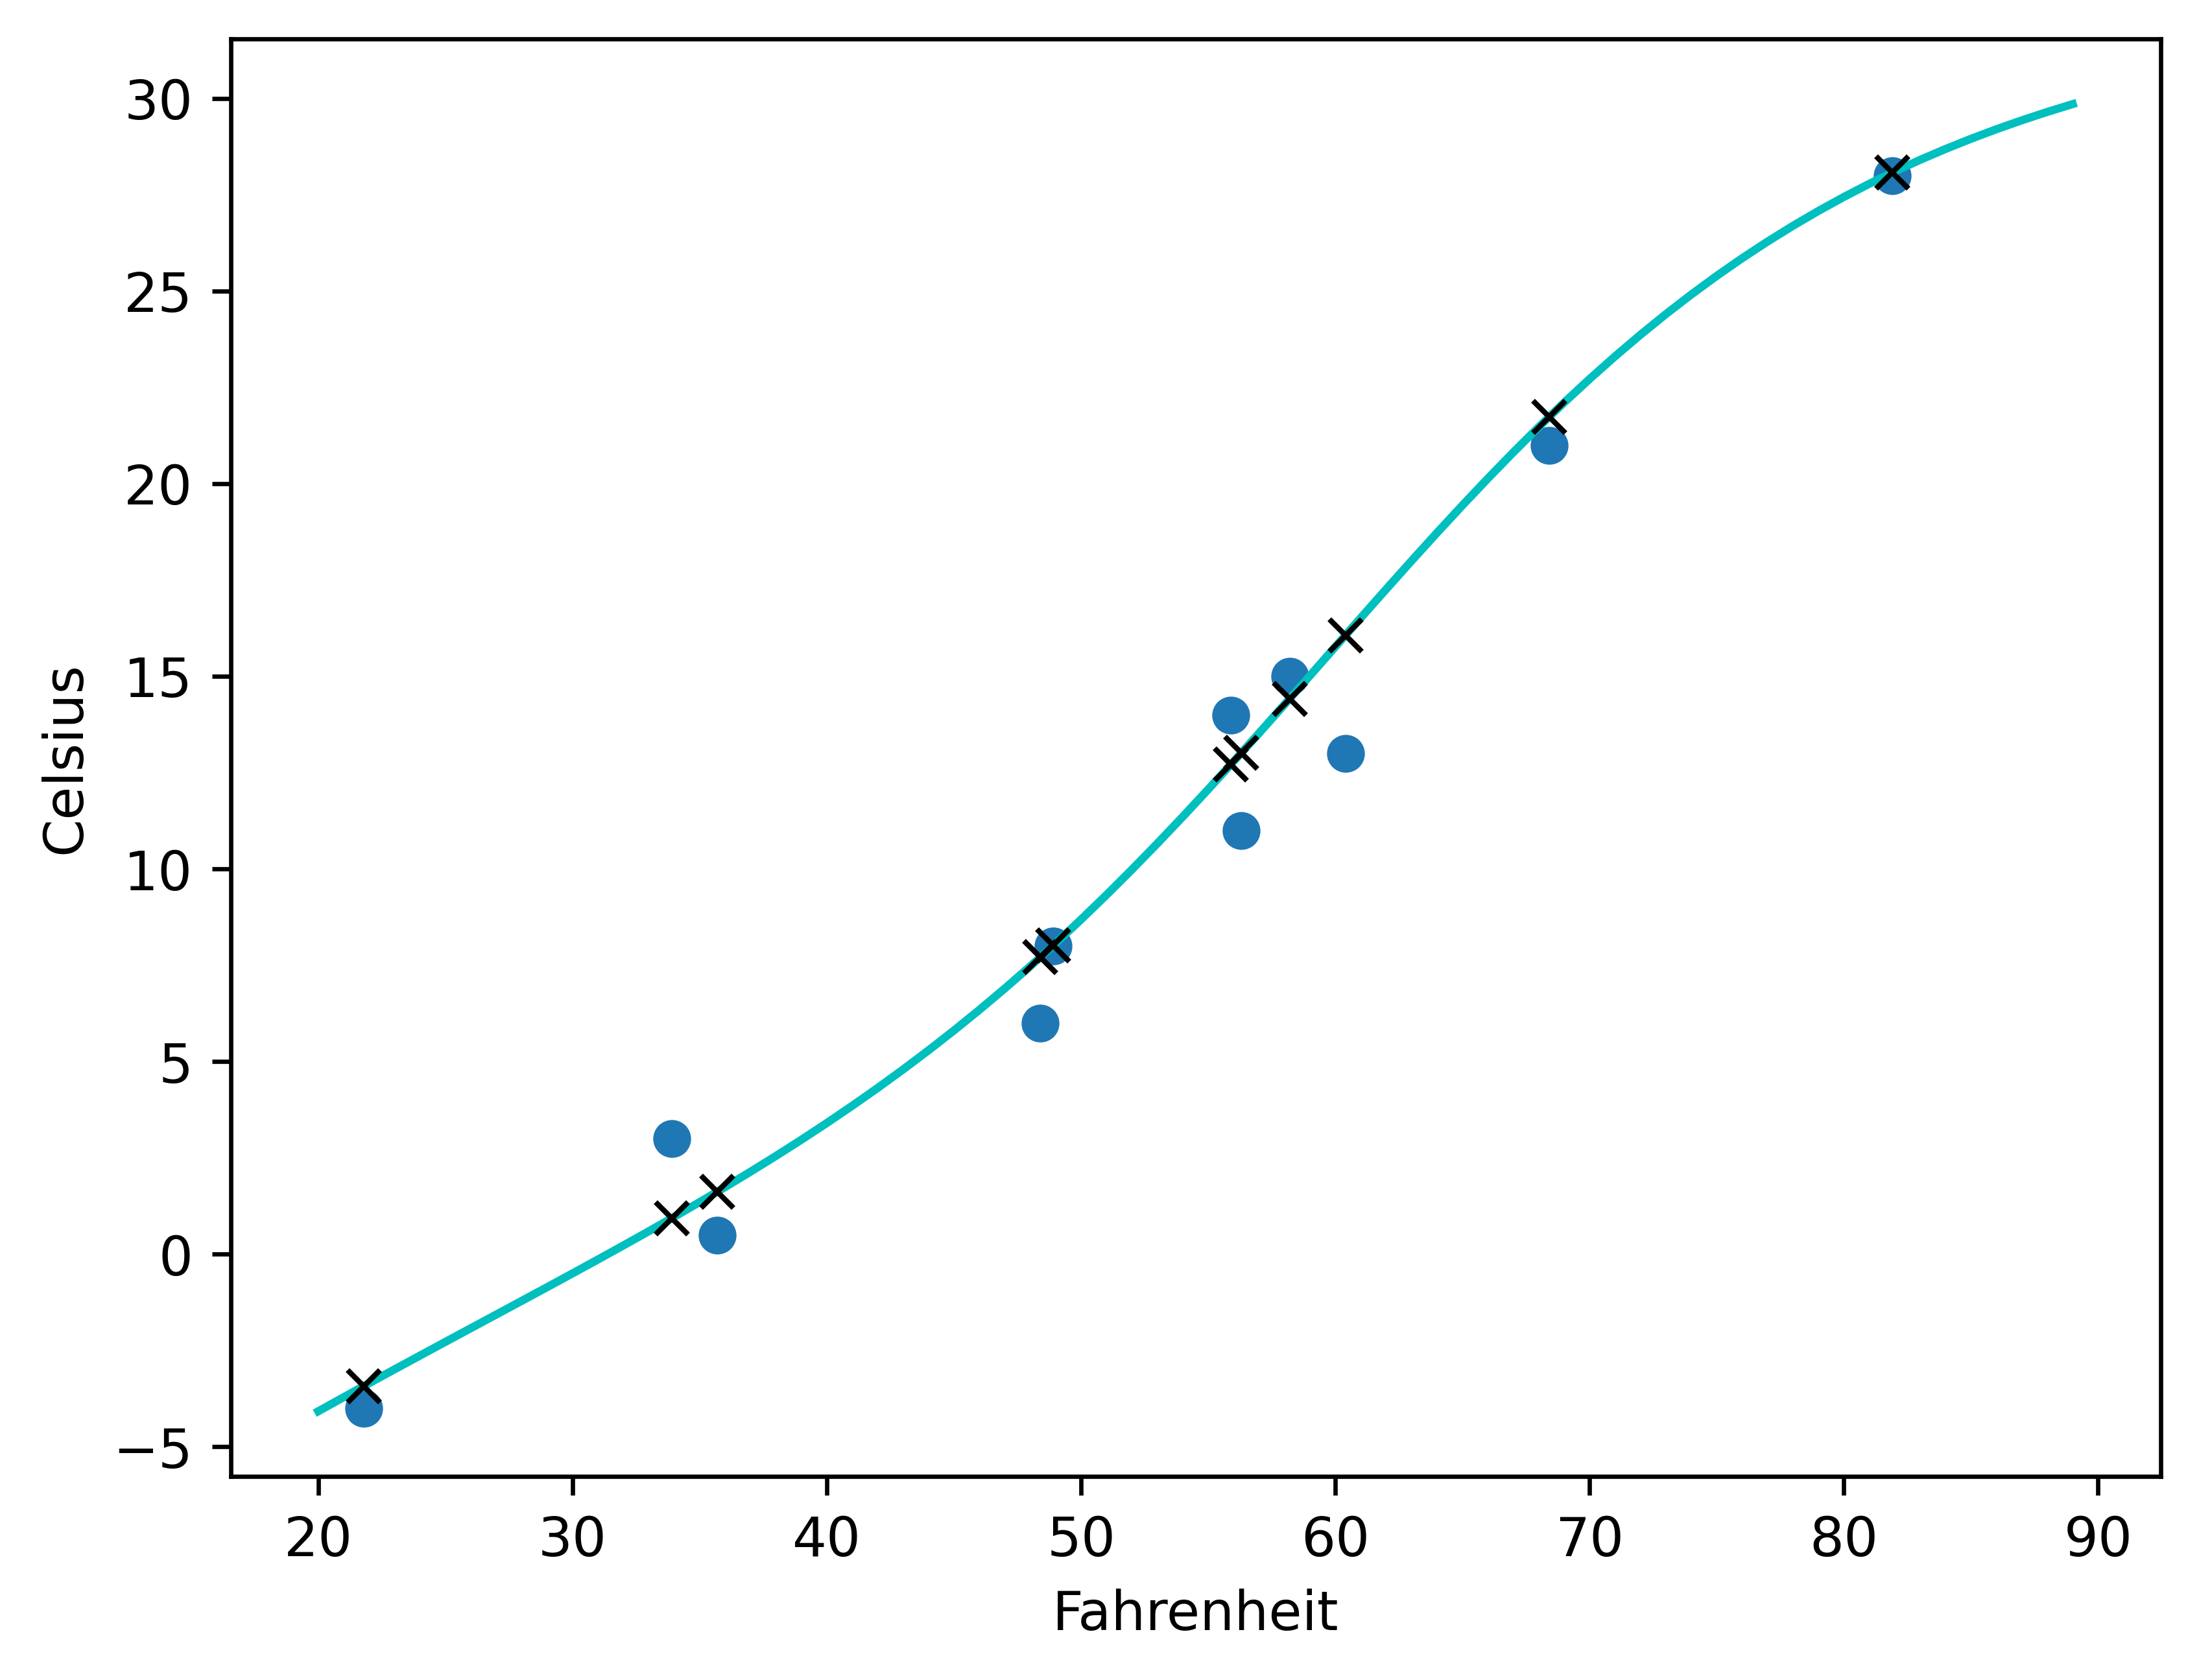

In [57]:
fig = plt.figure(dpi=600)
plt.xlabel('Fahrenheit')
plt.ylabel('Celsius')
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1*t_range).detach().numpy(),'c-')
plt.plot(t_u.numpy(), seq_model(0.1*t_u).detach().numpy(),'kx')